# IMPORTING DATA AND LIBRARIES

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score

In [2]:
#Load csv (dataset)
df = pd.read_csv('diabetes.csv')

In [3]:
#Load csv (dataset)
df = pd.read_csv('diabetes.csv')
#Load csv (dataset)
df = pd.read_csv('diabetes.csv')
#Display head()
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# PRE-PROCESSING DATA

In [4]:
from sklearn.impute import SimpleImputer

# Checking for missing values
print(df.isnull().sum())

# Impute missing values using mean strategy
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Checking for missing values after handling
print("\nAfter SimpleImputer")
print(df_imputed.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

After SimpleImputer
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


- FINDING THE FEATURES THAT IS HIGH IN CORRELATION TO THE TARGET (OUTCOME)

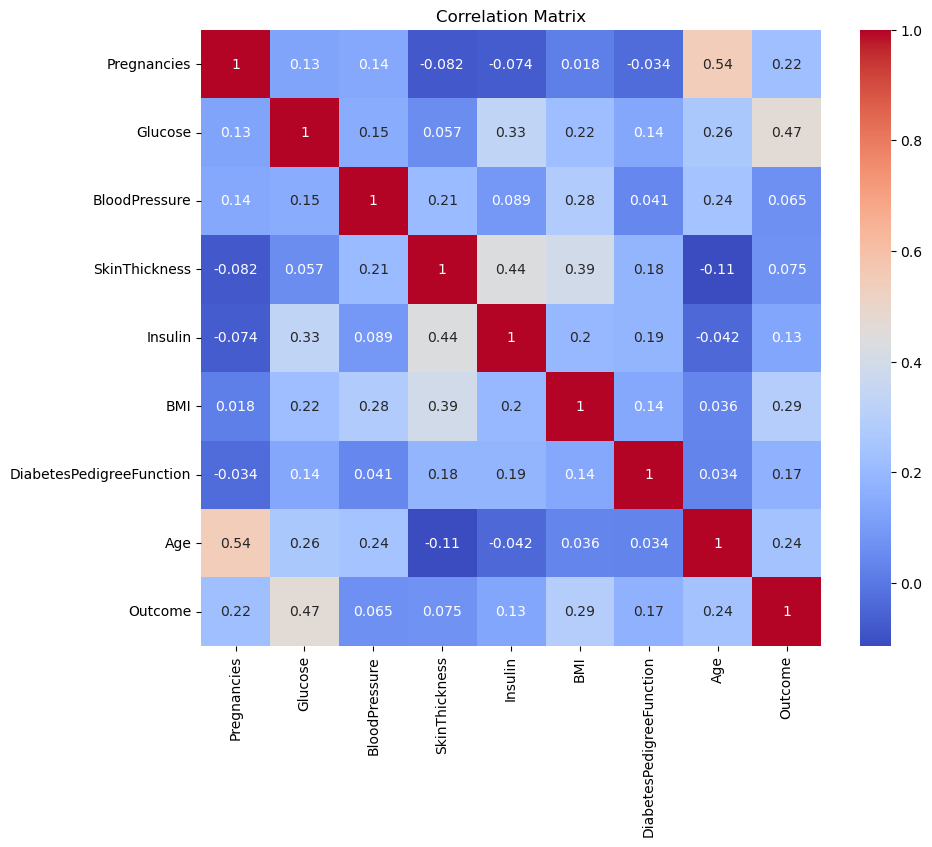

In [5]:
# Correlation Matrix
corr = df_imputed.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

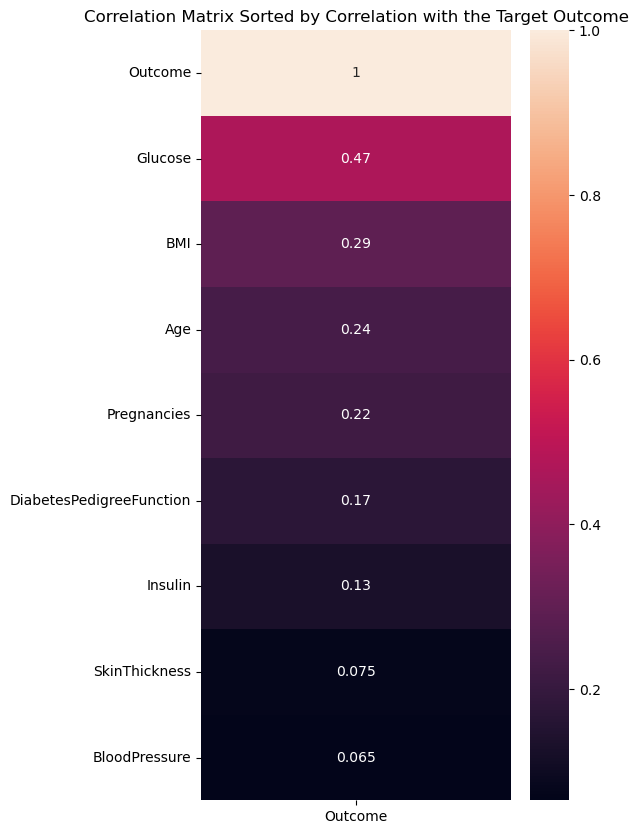

In [6]:
plt.figure(figsize=(5, 10))
target_variable = 'Outcome' 
sns.heatmap(df.corr().abs()[[target_variable]].sort_values(by=target_variable, ascending=False), annot=True)
plt.title("Correlation Matrix Sorted by Correlation with the Target Outcome")
plt.show()


- Skin Thickness and BloodPressure has too low correlation to the target

- Dropping features with Low Correlation to the outcome

In [7]:
#Drop SkinThickness and BloodPressure
df = df.drop(['SkinThickness', 'BloodPressure',], axis=1)



- The model should predict whether the patient has diabetes that will determine Outcome 1 and does not have Outcome 2, based on the included diagnostic measurements above

In [8]:
#Checking if there is null and differences in count to make the data accurate
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   Insulin                   768 non-null    int64  
 3   BMI                       768 non-null    float64
 4   DiabetesPedigreeFunction  768 non-null    float64
 5   Age                       768 non-null    int64  
 6   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 42.1 KB


Pregnancies                 0
Glucose                     0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

- There is no null in the data, meaning there is no missing values

- The dataframe now includes features with strong correlation to the target

# SPLITTING DATA AND TESTING

- Split and Scale Data

In [9]:
#The data will now be split to 30% testing and 70% training
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [10]:
print("Mean of X:", np.mean(X), ", Standard Deviation of X:", np.std(X))
print("Mean of X_train_scaled:", np.mean(X_train_scaled), ", Standard Deviation of X_train_scaled:", np.std(X_train_scaled))

Mean of X: 45.04073372395833 , Standard Deviation of X: Pregnancies                   3.367384
Glucose                      31.951796
Insulin                     115.168949
BMI                           7.879026
DiabetesPedigreeFunction      0.331113
Age                          11.752573
dtype: float64
Mean of X_train_scaled: 5.182419084532078e-17 , Standard Deviation of X_train_scaled: 1.0


# TRAINING AND TESTING MODELS

In [11]:
!pip install xgboost

In [12]:
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier 

In [13]:
models = {
    "SGDC": SGDClassifier(),
    "GNB": GaussianNB(),
    "LR": LogisticRegression(), 
    "RFt": RandomForestClassifier(),
    "DT": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),                               
    "ABC": AdaBoostClassifier(), 
    "GBC": GradientBoostingClassifier(),  
    "XG": XGBClassifier() 
}

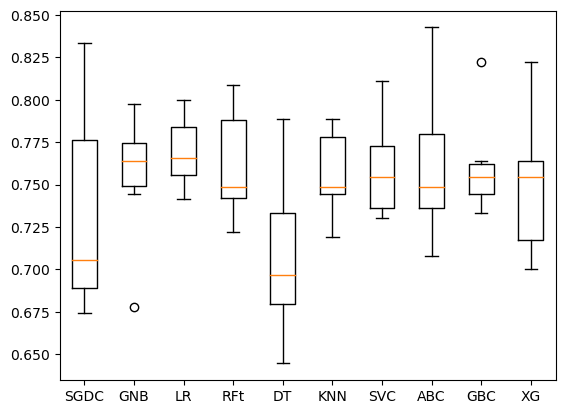

In [14]:
results = []
for model_name, model in models.items():
    kf = KFold(n_splits=6, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.show()

- Cross Validation Highest: GaussianNB

In [26]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    test_score_percentage = test_score * 100
    print("{} Test Set Accuracy: {:.2f}%".format(name, test_score_percentage))

SGDC Test Set Accuracy: 68.40%
GNB Test Set Accuracy: 75.76%
LR Test Set Accuracy: 73.59%
RFt Test Set Accuracy: 75.32%
DT Test Set Accuracy: 71.43%
KNN Test Set Accuracy: 68.83%
SVC Test Set Accuracy: 77.06%
ABC Test Set Accuracy: 75.32%
GBC Test Set Accuracy: 72.73%
XG Test Set Accuracy: 70.56%


- Accuracy
- SVC (77.06%)
- GNB (75.76%)
- RFt (75.32%)

- Confusion Matrix Test

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score, f1_score


for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name}:\n")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print ('Recall:', recall_score(y_test, y_pred))
    print('Accuracy:', accuracy_score(y_test, y_pred))
    print ('F1 score:', f1_score(y_test, y_pred))
    print("\n\n")


SGDC:

[[134  17]
 [ 47  33]]
              precision    recall  f1-score   support

           0       0.74      0.89      0.81       151
           1       0.66      0.41      0.51        80

    accuracy                           0.72       231
   macro avg       0.70      0.65      0.66       231
weighted avg       0.71      0.72      0.70       231

Recall: 0.4125
Accuracy: 0.7229437229437229
F1 score: 0.5076923076923077



GNB:

[[122  29]
 [ 27  53]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       151
           1       0.65      0.66      0.65        80

    accuracy                           0.76       231
   macro avg       0.73      0.74      0.73       231
weighted avg       0.76      0.76      0.76       231

Recall: 0.6625
Accuracy: 0.7575757575757576
F1 score: 0.654320987654321



LR:

[[123  28]
 [ 33  47]]
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       151

- Random Forest Classifier F1 score (64.32%)
- GaussianNB (65.43%)


# BUILDING THE MODELS

- SGDC MODEL

In [27]:
sgd_model = SGDClassifier(random_state=42)

# Train the model
sgd_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = sgd_model.predict(X_train_scaled)
y_pred_test = sgd_model.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train) * 100
test_accuracy = accuracy_score(y_test, y_pred_test) * 100

# Print accuracies
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)


Training Accuracy: 74.487895716946
Testing Accuracy: 70.995670995671


- GNB MODEL

In [28]:
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)

# Calculate training and testing
train_accuracy = accuracy_score(y_train, gnb_model.predict(X_train_scaled))*100
test_accuracy = accuracy_score(y_test, gnb_model.predict(X_test_scaled))*100

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 76.72253258845437
Testing Accuracy: 75.75757575757575


- LOGISTIC REGRESSION CLASSIFIER MODEL

In [29]:
log_reg = LogisticRegression(C=1, penalty='l2', solver='liblinear', max_iter=200)
log_reg.fit(X_train_scaled, y_train)

# Predicting on the testing set
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Calculate testing accuracy
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
accuracy_log_reg_percentage = accuracy_log_reg * 100
print("Accuracy of Logistic Regression on Testing: {:.2f}%".format(accuracy_log_reg_percentage))


Accuracy of Logistic Regression on Testing: 73.59%


- RANDOM FOREST CLASSIFIER MODEL

In [30]:
rfm = RandomForestClassifier(n_jobs=-1, random_state=42)

# Fit the model to the training data
rfm.fit(X_train, y_train)

# Make predictions on the training data
y_train_pred = rfm.predict(X_train)

# Make predictions on the testing data
y_test_pred = rfm.predict(X_test)

# Calculate 
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print the accuracies
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 100.00%
Testing Accuracy: 75.32%


- DECISION TREE MODEL

In [31]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
decision_tree_model.fit(X_train, y_train)

# Calculate
train_accuracy = decision_tree_model.score(X_train, y_train)
test_accuracy = decision_tree_model.score(X_test, y_test)*100

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 69.6969696969697


- KNEIGHBORS CLASSIFIER

In [32]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

# Calculate
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8417132216014898
Testing Accuracy: 0.6883116883116883


- SVC MODEL

In [33]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Calculate
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7746741154562383
Testing Accuracy: 0.7359307359307359


- ADABOOST MODEL

In [125]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_adaboost = adaboost_model.predict(X_train_scaled)
y_test_pred_adaboost = adaboost_model.predict(X_test_scaled)

# Calculate
train_accuracy_adaboost = accuracy_score(y_train, y_train_pred_adaboost)
test_accuracy_adaboost = accuracy_score(y_test, y_test_pred_adaboost)

print("AdaBoost Training Accuracy:", train_accuracy_adaboost)
print("AdaBoost Testing Accuracy:", test_accuracy_adaboost)

AdaBoost Training Accuracy: 0.8491620111731844
AdaBoost Testing Accuracy: 0.7532467532467533


- GRADIENT BOOST CLASSIFIER MODEL

In [126]:
gbm_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gbm_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_gbm = gbm_model.predict(X_train_scaled)
y_test_pred_gbm = gbm_model.predict(X_test_scaled)

# Calculate
train_accuracy_gbm = accuracy_score(y_train, y_train_pred_gbm)
test_accuracy_gbm = accuracy_score(y_test, y_test_pred_gbm)

print("GBM Training Accuracy:", train_accuracy_gbm)
print("GBM Testing Accuracy:", test_accuracy_gbm)

GBM Training Accuracy: 0.9329608938547486
GBM Testing Accuracy: 0.7316017316017316


- XGBOOST MODEL

In [127]:
xgboost_model = XGBClassifier(n_estimators=100, max_depth=3, random_state=42)

# Fit the XGBoost model to the training data
xgboost_model.fit(X_train_scaled, y_train)

# Make predictions on the training data
y_train_pred_xgboost = xgboost_model.predict(X_train_scaled)

# Make predictions on the validation data
y_val_pred_xgboost = xgboost_model.predict(X_test_scaled)

# Calculate the training accuracy
train_accuracy_xgboost = accuracy_score(y_train, y_train_pred_xgboost)

# Calculate the validation accuracy
val_accuracy_xgboost = accuracy_score(y_test, y_val_pred_xgboost)

# Print the training and validation accuracies
print("XGBoost Training Accuracy:", train_accuracy_xgboost)
print("XGBoost Testing Accuracy:", val_accuracy_xgboost)


XGBoost Training Accuracy: 0.9813780260707635
XGBoost Testing Accuracy: 0.7489177489177489


- The highest testing accuracy when building model
- Random Forest Classifier (75.32%) tied with GaussianNB (75.75%)

# TUNING AND PREDICTING USING THE SELECTED ACCURACY MODEL



- DISPLAY CLASSIFICATION REPORT AND ROC CURVE

- The Random Forest Classifier achieves one of the highest and consistent testing accuracy among all models, and its accuracy further improves when tuned.

In [148]:
from sklearn.model_selection import GridSearchCV

#Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [200,300,400],
    'max_depth': [None, 15, 20],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'] 
}

# model for Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Fit the GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Print Best Parameters found by GridSearchCV
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Best estimator found by GridSearchCV
best_estimator = grid_search.best_estimator_

# Make predictions on the testing data using the best estimator
y_test_pred_tuned = best_estimator.predict(X_test_scaled)

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred_tuned)*100

# Print the testing accuracy
print("Testing Accuracy after fine-tuning:", test_accuracy)


Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Testing Accuracy after fine-tuning: 76.62337662337663


- The accuracy increased from 75.32% to 76.62%.

Classification Report for Tuned RandomForestClassifier:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82       151
           1       0.65      0.71      0.68        80

    accuracy                           0.77       231
   macro avg       0.74      0.75      0.75       231
weighted avg       0.77      0.77      0.77       231



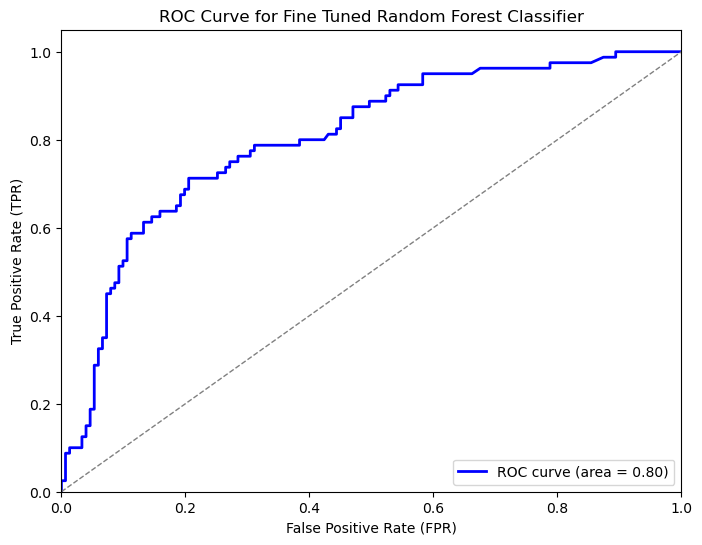

In [155]:
# Generate classification report
classification_rep_tuned_rfm = classification_report(y_test, y_test_pred_tuned)

# Print the classification report
print("Classification Report for Tuned RandomForestClassifier:\n", classification_rep_tuned_rfm)


# Get predicted probabilities for positive class
y_test_probs = best_estimator.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Fine Tuned Random Forest Classifier')
plt.legend(loc="lower right")
plt.show()

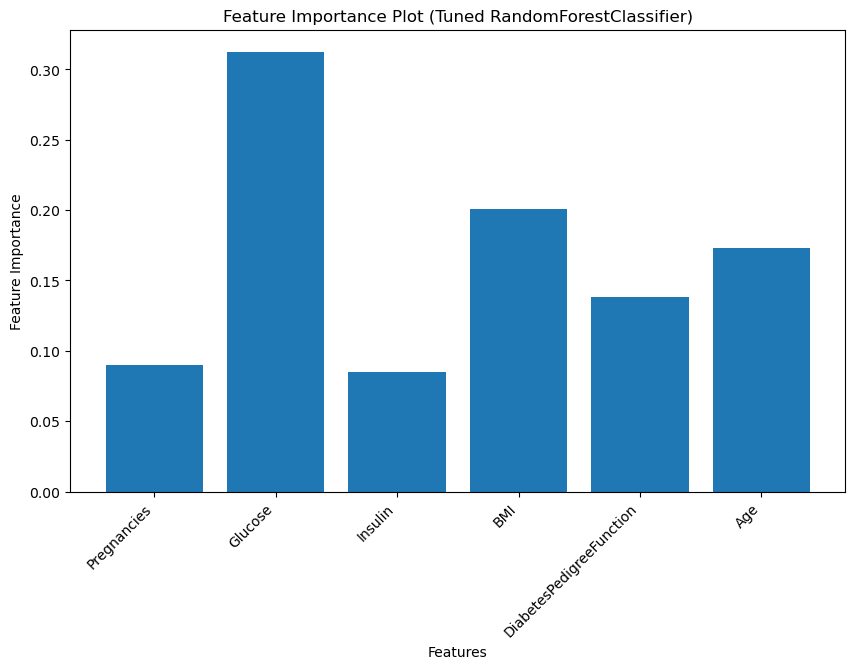

In [153]:
# Getting the feature importance of the tuned Random Forest Classifier
feature_importances_tuned_rfm = grid_search.best_estimator_.feature_importances_

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(X.columns, feature_importances_tuned_rfm)
plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Feature Importance Plot (Tuned RandomForestClassifier)')
plt.xticks(rotation=45, ha='right')
plt.show()


- Glucose has the highest importance and influence, 
- this means that in this model Random Forest Classifier, it contributed more than other diagnostic measures to make the model's decision-making process

- Performance Metrics of Tuned and Untuned

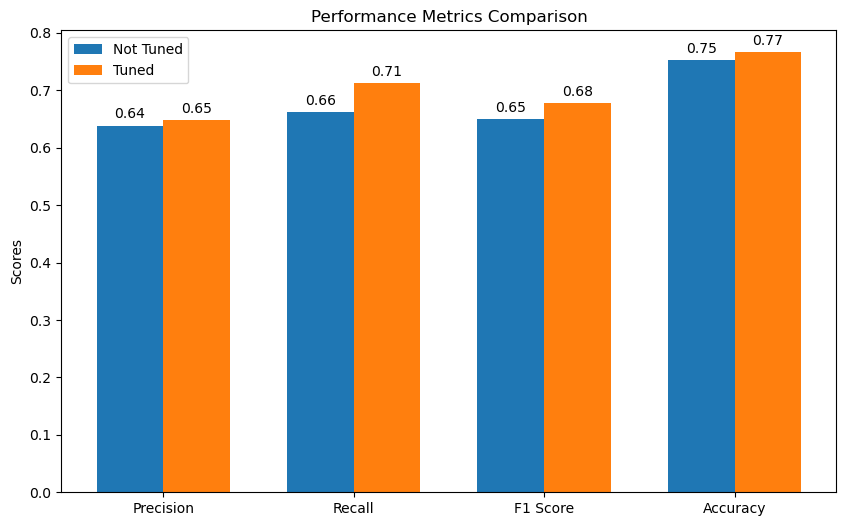

In [156]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Define performance metrics
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']

# Performance metrics for not tuned Random Forest Classifier
rfm_metrics = [precision_score(y_test, y_test_pred), recall_score(y_test, y_test_pred),
               f1_score(y_test, y_test_pred), accuracy_score(y_test, y_test_pred)]

# Performance metrics for tuned Random Forest Classifier
tuned_rfm_metrics = [precision_score(y_test, y_test_pred_tuned), recall_score(y_test, y_test_pred_tuned),
                     f1_score(y_test, y_test_pred_tuned), accuracy_score(y_test, y_test_pred_tuned)]

x = np.arange(len(metrics))

# Plotting the bar graph
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, rfm_metrics, width, label='Not Tuned')
rects2 = ax.bar(x + width/2, tuned_rfm_metrics, width, label='Tuned')

# Add labels, title, and legend
ax.set_ylabel('Scores')
ax.set_title('Performance Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Add data labels
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(round(height, 2)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

plt.show()


- It can be concluded that after tuning, the all metrics improved.

-  The accuracy is increased by 1.3% overall.